In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Suppose you have some data
data = {'Hours': [2, 3, 5, 7], 'Attendance': [80, 85, 90, 95], 'Marks': [50, 55, 70, 85]}
df = pd.DataFrame(data)

# If dataset is given in question
# # Load CSV
# df = pd.read_csv('yourfile.csv')

X = df[['Hours', 'Attendance']]  # Features
y = df['Marks']  # Target

##### Syntax: 
`
DataFrameName.insert(loc, column, value) 
`

In [21]:
# Add a column of ones for intercept
X.insert(0, 'Ones', 1)


# Convert to numpy arrays
X = X.values
y = y.values.reshape(-1, 1)


# Apply Normal Equation
b = np.linalg.inv(X.T @ X) @ X.T @ y

print("Coefficients are:", b)

# Predict function
def predict(x):
    # np.insert(array, index, value)
    x_b = np.insert(x, 0, 1)  # Add bias term (intercept)
    return x_b @ b

# Example prediction
new_student = [4, 88]  # 4 hours studied and 88% attendance
predicted_marks = predict(new_student)
print("Predicted Marks:", predicted_marks)


# Predict on training data
y_pred = X @ b

Coefficients are: [[110.]
 [ 10.]
 [ -1.]]
Predicted Marks: [62.]


In [22]:
# Evaluation metrics
def rmse(y, y_pred):
    n = len(y)
    squared_errors = (y - y_pred) ** 2
    mse = np.sum(squared_errors) / n
    rmse = np.sqrt(mse)
    return rmse


def r2_score(y, y_pred):
    sse = np.sum((y - y_pred) ** 2)
    sst = np.sum((y - np.mean(y)) ** 2)
    return 1 - (sse / sst)

print("RMSE:", rmse(y, y_pred))
print("R² Score:", r2_score(y, y_pred))

RMSE: 1.0321483774110706e-11
R² Score: 1.0


In [24]:
H = np.linspace(df['Hours'].min(), df['Hours'].max(), 10)
A = np.linspace(df['Attendance'].min(), df['Attendance'].max(), 10)

H, A

(array([2.        , 2.55555556, 3.11111111, 3.66666667, 4.22222222,
        4.77777778, 5.33333333, 5.88888889, 6.44444444, 7.        ]),
 array([80.        , 81.66666667, 83.33333333, 85.        , 86.66666667,
        88.33333333, 90.        , 91.66666667, 93.33333333, 95.        ]))

In [26]:
H, A = np.meshgrid(H, A)

H, A

(array([[2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ],
        [2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ],
        [2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ],
        ...,
        [2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ],
        [2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ],
        [2.        , 2.55555556, 3.11111111, ..., 5.88888889, 6.44444444,
         7.        ]], shape=(100, 100)),
 array([[80., 80., 80., ..., 80., 80., 80.],
        [80., 80., 80., ..., 80., 80., 80.],
        [80., 80., 80., ..., 80., 80., 80.],
        ...,
        [95., 95., 95., ..., 95., 95., 95.],
        [95., 95., 95., ..., 95., 95., 95.],
        [95., 95., 95., ..., 95., 95., 95.]], shape=(100, 100)))

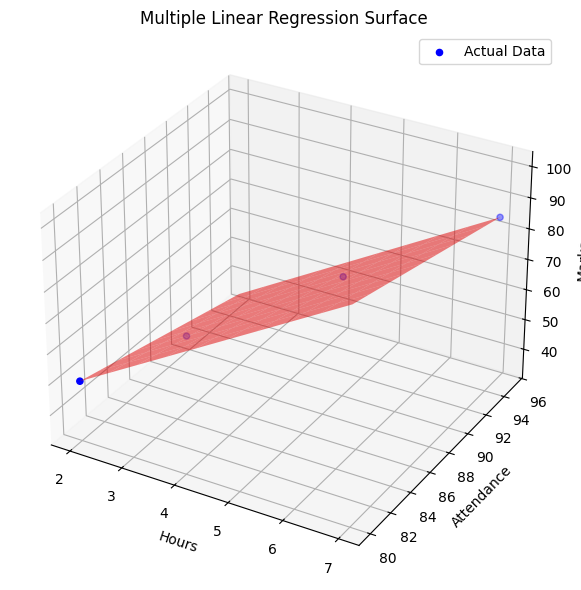

In [29]:
# #Plotting
# Create a grid of Hours and Attendance
H = np.linspace(df['Hours'].min(), df['Hours'].max(), 10)
A = np.linspace(df['Attendance'].min(), df['Attendance'].max(), 10)


H, A = np.meshgrid(H, A)

# Directly calculate predicted Marks
Marks = b[0] + b[1] * H + b[2] * A

# Plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(H, A, Marks, color='red', alpha=0.5)

# Actual data points (optional, to show actual samples)
ax.scatter(df['Hours'], df['Attendance'], df['Marks'], color='blue', label='Actual Data')

# Labels
ax.set_xlabel('Hours')
ax.set_ylabel('Attendance')
ax.set_zlabel('Marks')
ax.set_title('Multiple Linear Regression Surface')

plt.legend()
plt.tight_layout()
plt.show()